# Southwest Airlines: Delay Analysis and Action Recommendations

## Problem Statement
How can Southwest Airlines use historical delay data to identify frequently delayed routes/airports and prioritize actions that reduce delays?

## Scope
- Focus: Southwest (WN) in dataset `dataset/southwest_airlines.csv`
- Level: Monthly level, aggregated per airport
- Time period: As available in dataset (e.g., 2013–2023 if available)
- Outcome: Delay defined as \(\ge 15\) minutes (`arr_del15`)
- Perspective: Arrivals and associated delay causes

## Objectives
- Map airports and periods with high delay rates
- Quantify most important delay causes (carrier, weather, NAS, security, late aircraft)
- Prioritize actions per airport/region based on effectiveness and feasibility

## Methodology (CRISP-DM)
1. Business Understanding
2. Data Understanding
3. Data Preparation
4. Analysis/Modeling (KPIs and visualization)
5. Evaluation (interpretation and actions)
6. Deployment (recommendations and monitoring)



In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Visual standards
sns.set(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)

DATA_PATH = Path("dataset/southwest_airlines.csv")
assert DATA_PATH.exists(), f"File not found: {DATA_PATH}"

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
df.head()


Shape: (11109, 21)


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,WN,Southwest Airlines Co.,ABQ,"Albuquerque, NM: Albuquerque International Sun...",1003.0,237.0,72.39,1.47,...,0.00,137.04,12.0,0.0,9768.0,2718.0,53.0,1114.0,0.0,5883.0
1,2023,8,WN,Southwest Airlines Co.,ALB,"Albany, NY: Albany International",312.0,107.0,45.40,1.00,...,0.00,45.25,4.0,0.0,5040.0,2004.0,50.0,484.0,0.0,2502.0
2,2023,8,WN,Southwest Airlines Co.,AMA,"Amarillo, TX: Rick Husband Amarillo International",207.0,33.0,12.80,0.00,...,0.00,16.42,1.0,0.0,989.0,403.0,0.0,93.0,0.0,493.0
3,2023,8,WN,Southwest Airlines Co.,ATL,"Atlanta, GA: Hartsfield-Jackson Atlanta Intern...",3143.0,717.0,183.49,26.09,...,0.00,288.91,34.0,15.0,41231.0,9166.0,2453.0,14291.0,0.0,15321.0
4,2023,8,WN,Southwest Airlines Co.,AUS,"Austin, TX: Austin - Bergstrom International",3169.0,623.0,185.41,11.02,...,2.52,312.24,32.0,10.0,29059.0,8067.0,816.0,3928.0,97.0,16151.0


In [2]:
# Standardize column names and types
original_cols = df.columns.tolist()
df.columns = [c.strip().lower() for c in df.columns]

# Ensure numeric types
numeric_cols = [
    'arr_flights','arr_del15','carrier_ct','weather_ct','nas_ct','security_ct','late_aircraft_ct',
    'arr_cancelled','arr_diverted','arr_delay','carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay'
]
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Create date field (year, month -> period and date)
if {'year','month'}.issubset(df.columns):
    df['year'] = df['year'].astype(int)
    df['month'] = df['month'].astype(int)
    df['year_month'] = pd.to_datetime(dict(year=df['year'], month=df['month'], day=1))
else:
    raise ValueError("Expected columns 'year' and 'month' in dataset")

print(df.dtypes.head(20))
df.tail(3)


year                  int64
month                 int64
carrier              object
carrier_name         object
airport              object
airport_name         object
arr_flights         float64
arr_del15           float64
carrier_ct          float64
weather_ct          float64
nas_ct              float64
security_ct         float64
late_aircraft_ct    float64
arr_cancelled       float64
arr_diverted        float64
arr_delay           float64
carrier_delay       float64
weather_delay       float64
nas_delay           float64
security_delay      float64
dtype: object


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,year_month
11106,2013,8,WN,Southwest Airlines Co.,PHX,"Phoenix, AZ: Phoenix Sky Harbor International",4986.0,1267.0,367.33,16.66,...,695.93,28.0,17.0,55837.0,15556.0,727.0,6081.0,87.0,33386.0,2013-08-01
11107,2013,8,WN,Southwest Airlines Co.,PIT,"Pittsburgh, PA: Pittsburgh International",535.0,164.0,49.05,3.81,...,92.04,0.0,1.0,7853.0,1932.0,264.0,884.0,0.0,4773.0,2013-08-01
11108,2013,8,WN,Southwest Airlines Co.,GRR,"Grand Rapids, MI: Gerald R. Ford International",123.0,39.0,17.81,0.00,...,13.28,1.0,0.0,1537.0,842.0,0.0,203.0,0.0,492.0,2013-08-01


In [3]:
# KPIs
# - delay_rate: proportion of delayed arrivals (>=15 min)
# - avg_delay_min_per_arrival: total delay time per arrival
# - cause_shares: proportions per delay cause

# Protection against division by zero
df['delay_rate'] = df['arr_del15'] / df['arr_flights']
df['avg_delay_min_per_arrival'] = df['arr_delay'] / df['arr_flights']

cause_delay_cols = ['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']
cause_ct_cols = ['carrier_ct','weather_ct','nas_ct','security_ct','late_aircraft_ct']

# Proportions of delay time per cause
cause_delay_sum = df[cause_delay_cols].sum(axis=1)
for col in cause_delay_cols:
    share_col = f"{col}_share"
    df[share_col] = np.where(cause_delay_sum > 0, df[col] / cause_delay_sum, np.nan)

# Proportion of delay incidents per cause (counts)
cause_ct_sum = df[cause_ct_cols].sum(axis=1)
for col in cause_ct_cols:
    share_col = f"{col}_share"
    df[share_col] = np.where(cause_ct_sum > 0, df[col] / cause_ct_sum, np.nan)

kpi_cols = ['delay_rate','avg_delay_min_per_arrival'] + [c+"_share" for c in (cause_delay_cols+cause_ct_cols)]
df[kpi_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
delay_rate,11109.0,0.205420,0.092726,0.0,0.143564,0.201717,0.263754,0.628415
avg_delay_min_per_arrival,11109.0,10.288931,5.559667,0.0,6.479042,9.536706,13.418284,43.165131
carrier_delay_share,11089.0,0.364873,0.121519,0.0,0.286482,0.346862,0.420000,1.000000
weather_delay_share,11089.0,0.027380,0.040905,0.0,0.000000,0.014295,0.036943,1.000000
nas_delay_share,11089.0,0.124668,0.090704,0.0,0.066493,0.102896,0.155853,1.000000
security_delay_share,11089.0,0.002427,0.010574,0.0,0.000000,0.000000,0.001471,0.464286
late_aircraft_delay_share,11089.0,0.480651,0.133633,0.0,0.413004,0.495450,0.567115,1.000000
carrier_ct_share,11089.0,0.378463,0.110874,0.0,0.305714,0.365806,0.433175,1.000000
weather_ct_share,11089.0,0.018406,0.028306,0.0,0.000000,0.010432,0.024872,1.000000
nas_ct_share,11089.0,0.155058,0.097881,0.0,0.088906,0.134687,0.199419,1.000000


,year_month,flights,delayed,delay_min,delay_rate,avg_delay_min_per_arrival
116,2023-04-01,115946.0,29278.0,1489957.0,0.252514,12.850439
117,2023-05-01,122521.0,25058.0,1169671.0,0.204520,9.546698
118,2023-06-01,119251.0,35058.0,1850536.0,0.293985,15.517991
119,2023-07-01,126469.0,39050.0,2208263.0,0.308771,17.460903
120,2023-08-01,125664.0,28374.0,1341692.0,0.225793,10.676821


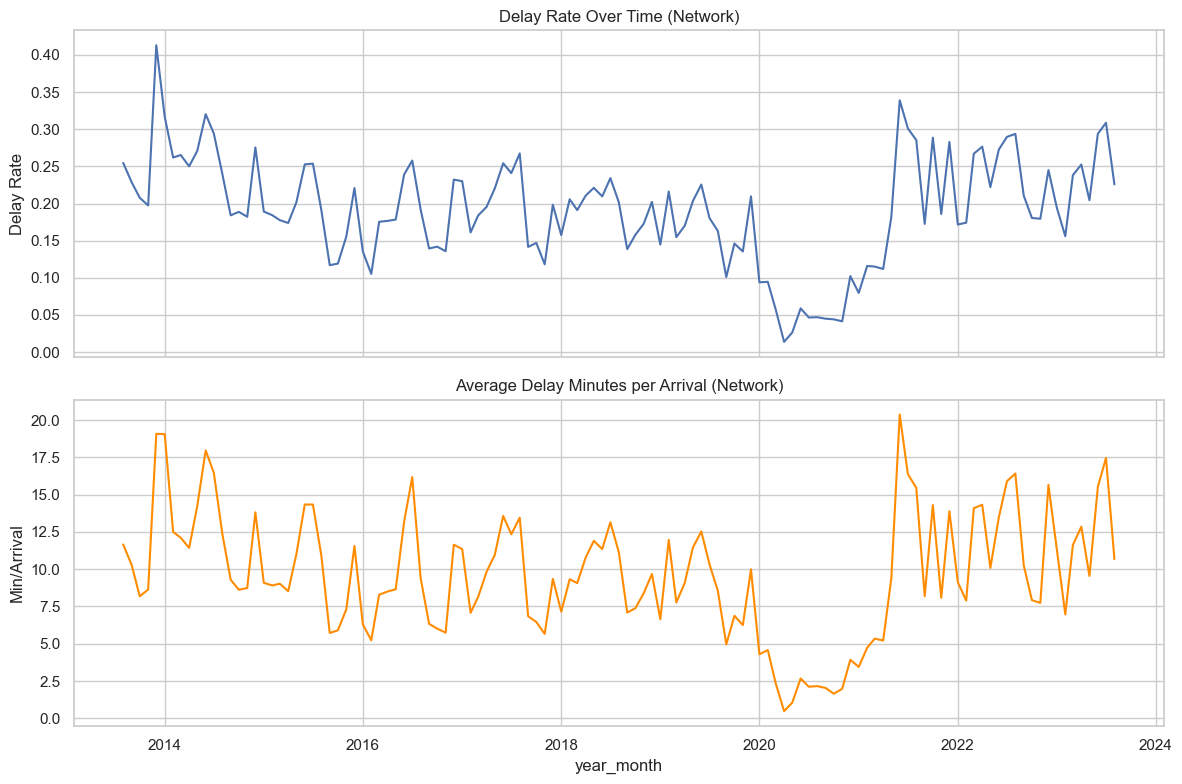

In [4]:
# Network level: time series and totals
net = df.groupby('year_month', as_index=False).agg(
    flights=('arr_flights','sum'),
    delayed=('arr_del15','sum'),
    delay_min=('arr_delay','sum')
)
net['delay_rate'] = net['delayed'] / net['flights']
net['avg_delay_min_per_arrival'] = net['delay_min'] / net['flights']

fig, axes = plt.subplots(2,1, figsize=(12,8), sharex=True)
sns.lineplot(data=net, x='year_month', y='delay_rate', ax=axes[0])
axes[0].set_title('Delay Rate Over Time (Network)')
axes[0].set_ylabel('Delay Rate')

sns.lineplot(data=net, x='year_month', y='avg_delay_min_per_arrival', ax=axes[1], color='darkorange')
axes[1].set_title('Average Delay Minutes per Arrival (Network)')
axes[1].set_ylabel('Min/Arrival')
plt.tight_layout()

net.tail()


/var/folders/91/1bgbqkxj2x95_0d2pc1vb63r0000gn/T/ipykernel_74649/2499326541.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rate, y='airport', x='delay_rate', ax=axes[0], palette='Reds_r')
/var/folders/91/1bgbqkxj2x95_0d2pc1vb63r0000gn/T/ipykernel_74649/2499326541.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_avg, y='airport', x='avg_delay_min_per_arrival', ax=axes[1], palette='Oranges_r')


,airport,flights,delayed,delay_min,delay_rate,avg_delay_min_per_arrival
94,SFO,8749.0,2751.0,139633.0,0.314436,15.959881
30,FAT,1418.0,445.0,21129.0,0.313822,14.900564
96,SJU,3651.0,1110.0,61910.0,0.304026,16.956998
25,DSM,1659.0,502.0,26761.0,0.302592,16.130802
10,BOS,5916.0,1741.0,93035.0,0.294287,15.725997
82,PWM,1366.0,399.0,17729.0,0.292094,12.978770
59,MEM,2949.0,853.0,44331.0,0.289251,15.032553
86,ROC,1926.0,557.0,27960.0,0.289200,14.517134
74,PBI,2095.0,605.0,32000.0,0.288783,15.274463
26,DTW,3792.0,1073.0,51065.0,0.282964,13.466508


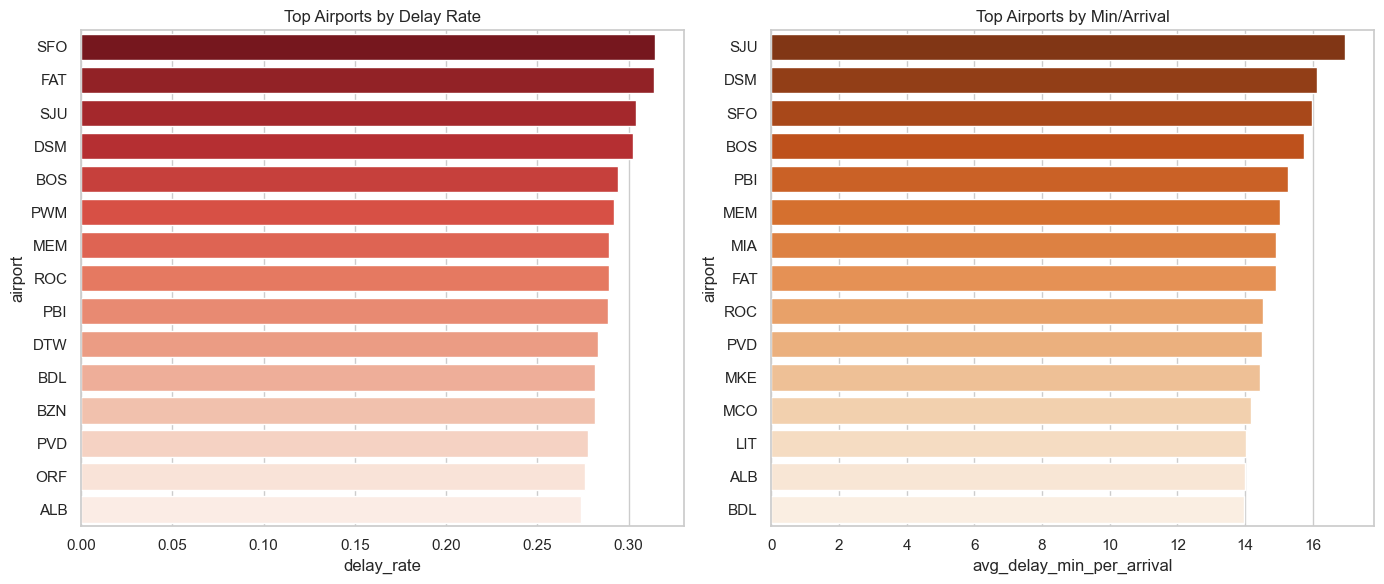

In [5]:
# Airport rankings (last 12 months or entire dataset if short)
# Take last 12 months if possible
last_date = df['year_month'].max()
first_date = df['year_month'].min()
if (last_date - first_date).days >= 365:
    cutoff = last_date - pd.DateOffset(years=1)
    df_rank = df[df['year_month'] > cutoff].copy()
else:
    df_rank = df.copy()

rank = df_rank.groupby('airport', as_index=False).agg(
    flights=('arr_flights','sum'),
    delayed=('arr_del15','sum'),
    delay_min=('arr_delay','sum')
)
rank['delay_rate'] = rank['delayed'] / rank['flights']
rank['avg_delay_min_per_arrival'] = rank['delay_min'] / rank['flights']

# Filter meaningful volume
rank = rank[rank['flights'] >= 200]

# Top 15 by delay_rate and by avg_delay
top_rate = rank.sort_values('delay_rate', ascending=False).head(15)
top_avg = rank.sort_values('avg_delay_min_per_arrival', ascending=False).head(15)

fig, axes = plt.subplots(1,2, figsize=(14,6))
sns.barplot(data=top_rate, y='airport', x='delay_rate', ax=axes[0], palette='Reds_r')
axes[0].set_title('Top Airports by Delay Rate')
sns.barplot(data=top_avg, y='airport', x='avg_delay_min_per_arrival', ax=axes[1], palette='Oranges_r')
axes[1].set_title('Top Airports by Min/Arrival')
plt.tight_layout()

rank.sort_values('delay_rate', ascending=False).head(10)


,airport,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,SFO,472753.0,96068.0,748685.0,1764.0,941433.0
1,FAT,18194.0,497.0,3795.0,82.0,26522.0
2,SJU,149971.0,21858.0,47392.0,2394.0,175193.0
3,DSM,39125.0,2192.0,9371.0,16.0,65509.0
4,BOS,368395.0,67299.0,271173.0,1454.0,443898.0


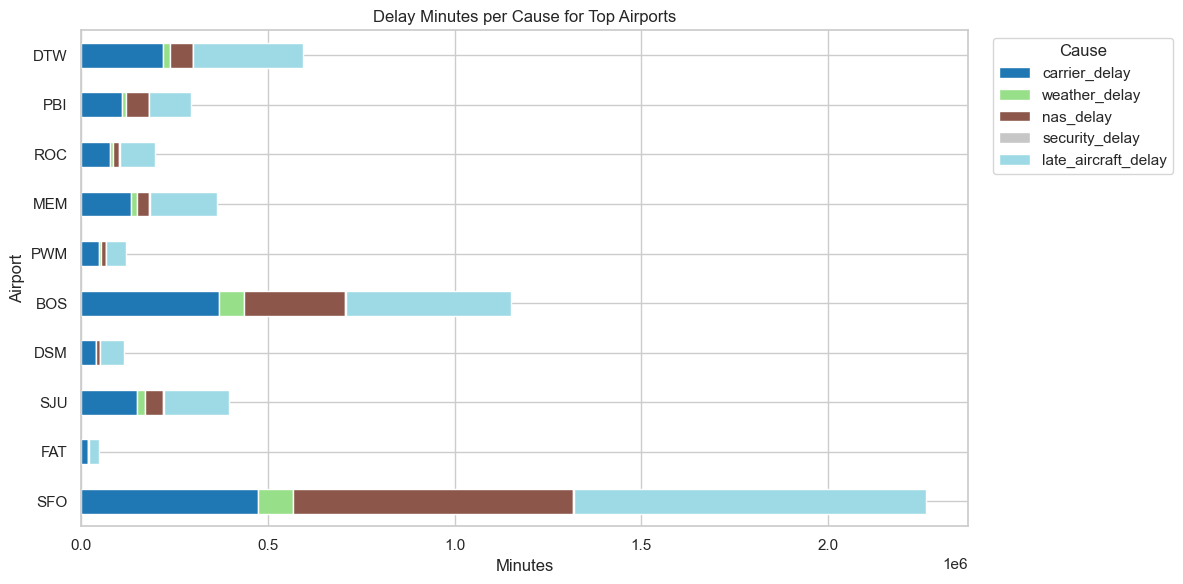

In [6]:
# Cause analysis for top delayed airports
# Select top N from rank
TOP_N = 10
focus_airports = rank.sort_values('delay_rate', ascending=False).head(TOP_N)['airport'].tolist()

cause_cols = ['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']
subset = df[df['airport'].isin(focus_airports)].copy()

cause_by_airport = subset.groupby('airport', as_index=False)[cause_cols].sum()
# Maintain order from focus_airports
cause_by_airport = cause_by_airport.set_index('airport').loc[focus_airports].reset_index()

# True stacked horizontal bar plot
ax = cause_by_airport.set_index('airport')[cause_cols].plot(
    kind='barh', stacked=True, figsize=(12,6), colormap='tab20'
)
ax.set_title('Delay Minutes per Cause for Top Airports')
ax.set_xlabel('Minutes')
ax.set_ylabel('Airport')
plt.legend(title='Cause', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()

cause_by_airport.head()


,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
airport,,,,,
BOS,0.319727,0.058408,0.235348,0.001262,0.385255
DSM,0.336666,0.018862,0.080636,0.000138,0.563698
DTW,0.368169,0.032646,0.103773,0.001649,0.493764
FAT,0.370625,0.010124,0.077307,0.001670,0.540273
MEM,0.366306,0.044390,0.092760,0.001632,0.494913


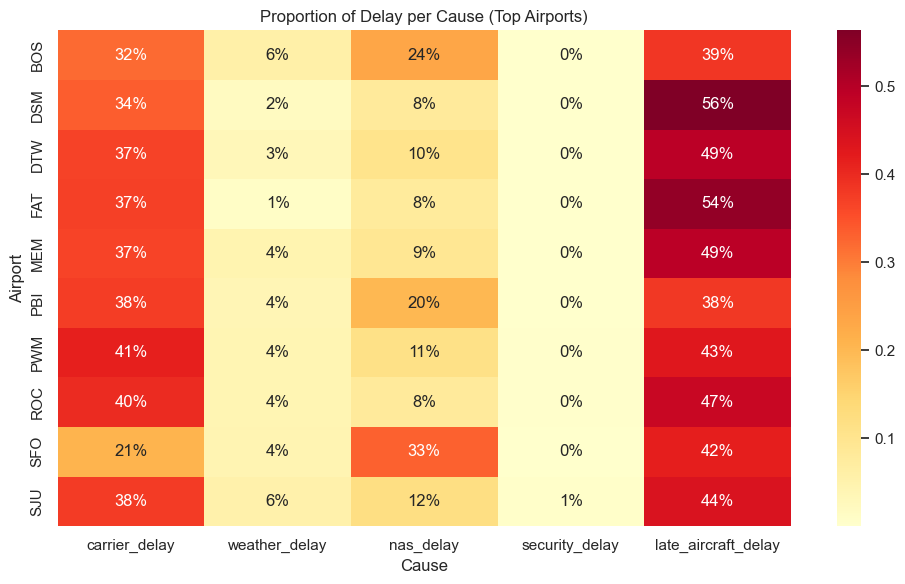

In [7]:
# Heatmap: proportion of delay time per cause (normalized per airport)
shares = subset.groupby('airport', as_index=False)[cause_cols].sum()
row_sum = shares[cause_cols].sum(axis=1)
share_matrix = shares.copy()
for c in cause_cols:
    share_matrix[c] = np.where(row_sum>0, shares[c]/row_sum, np.nan)

# Present heatmap
heat = share_matrix.set_index('airport')[cause_cols]
plt.figure(figsize=(10,6))
sns.heatmap(heat, annot=True, fmt='.0%', cmap='YlOrRd')
plt.title('Proportion of Delay per Cause (Top Airports)')
plt.ylabel('Airport')
plt.xlabel('Cause')
plt.tight_layout()

heat.head()


In [8]:
# Prioritization logic: combine volume and risk
prior = rank.copy()

# Normalize indicators 0-1
for col in ['flights','delay_rate','avg_delay_min_per_arrival']:
    m, M = prior[col].min(), prior[col].max()
    prior[f'{col}_norm'] = np.where(M>m, (prior[col]-m)/(M-m), 0.0)

# Weighted priority score (adjustable)
# Weighs both volume and severity
prior['priority_score'] = 0.4*prior['flights_norm'] + 0.3*prior['delay_rate_norm'] + 0.3*prior['avg_delay_min_per_arrival_norm']

# Add dominant cause
cause_cols = ['carrier_delay','weather_delay','nas_delay','security_delay','late_aircraft_delay']
recent_subset = df_rank.groupby('airport', as_index=False)[cause_cols].sum()
recent_subset['dominant_cause'] = recent_subset[cause_cols].idxmax(axis=1)

prior = prior.merge(recent_subset[['airport','dominant_cause']], on='airport', how='left')

priorities = prior.sort_values('priority_score', ascending=False).head(15)
priorities[['airport','flights','delay_rate','avg_delay_min_per_arrival','dominant_cause','priority_score']].reset_index(drop=True)


,airport,flights,delay_rate,avg_delay_min_per_arrival,dominant_cause,priority_score
0,LAS,81836.0,0.256342,13.258138,late_aircraft_delay,0.725998
1,DEN,92612.0,0.223686,12.329417,late_aircraft_delay,0.681529
2,SFO,8749.0,0.314436,15.959881,late_aircraft_delay,0.603773
3,SJU,3651.0,0.304026,16.956998,late_aircraft_delay,0.593337
4,DSM,1659.0,0.302592,16.130802,late_aircraft_delay,0.555851
5,MCO,39502.0,0.244443,14.182649,late_aircraft_delay,0.548499
6,BOS,5916.0,0.294287,15.725997,late_aircraft_delay,0.545810
7,FAT,1418.0,0.313822,14.900564,late_aircraft_delay,0.537261
8,MDW,76876.0,0.203418,10.940541,late_aircraft_delay,0.530740
9,DAL,69849.0,0.204670,11.115735,late_aircraft_delay,0.508089


In [9]:
# Action recommendations based on dominant causes
reco_map = {
    'carrier_delay': 'Increase buffer in rotation plan, strengthen maintenance and ground staffing.',
    'weather_delay': 'Seasonal and weather planning: flexible slots, extra reserve aircraft/crew.',
    'nas_delay': 'Coordinate with ATC; adjust departure times; spread traffic during peak.',
    'security_delay': 'Optimize security processes; better coordination with TSA.',
    'late_aircraft_delay': 'Better block times, turnaround efficiency, reserve aircraft to break cascade effects.'
}

priorities['recommendation'] = priorities['dominant_cause'].map(reco_map)

priorities[['airport','dominant_cause','recommendation','priority_score']].head(10)


,airport,dominant_cause,recommendation,priority_score
48,LAS,late_aircraft_delay,"Better block times, turnaround efficiency, res...",0.725998
24,DEN,late_aircraft_delay,"Better block times, turnaround efficiency, res...",0.681529
94,SFO,late_aircraft_delay,"Better block times, turnaround efficiency, res...",0.603773
96,SJU,late_aircraft_delay,"Better block times, turnaround efficiency, res...",0.593337
25,DSM,late_aircraft_delay,"Better block times, turnaround efficiency, res...",0.555851
57,MCO,late_aircraft_delay,"Better block times, turnaround efficiency, res...",0.548499
10,BOS,late_aircraft_delay,"Better block times, turnaround efficiency, res...",0.545810
30,FAT,late_aircraft_delay,"Better block times, turnaround efficiency, res...",0.537261
58,MDW,late_aircraft_delay,"Better block times, turnaround efficiency, res...",0.530740
22,DAL,late_aircraft_delay,"Better block times, turnaround efficiency, res...",0.508089


In [10]:
# Export key tables to CSV
out_dir = Path('dataset')
out_dir.mkdir(parents=True, exist_ok=True)

rank.to_csv(out_dir / 'southwest_airports_rank.csv', index=False)
priorities.to_csv(out_dir / 'southwest_priorities.csv', index=False)

print('Saved:', out_dir / 'southwest_airports_rank.csv')
print('Saved:', out_dir / 'southwest_priorities.csv')


Saved: dataset/southwest_airports_rank.csv
Saved: dataset/southwest_priorities.csv


## Interpretation and Actions

- **High-risk airports**: Based on `priority_score` and delay profile.
- **Dominant causes**: See heatmap and `dominant_cause` per airport.
- **Operational actions** (examples):
  - Carrier/operational: Optimize rotations, increase buffer in block times, staffing and maintenance.
  - Late aircraft: Reserve aircraft/crew to break cascade effects; improve turnaround.
  - NAS: Adjust departures to ATC capacity; spread peak traffic.
  - Weather: Seasonal adaptation; alternative slots; pre-tactical planning.
  - Security: Streamline ground processes and coordination.

## Scope and Limitations
- Data structure: Aggregated monthly figures per airport – route level missing.
- Cause attributes: May overlap and be influenced by reporting practices.
- Not included: Cost/benefit calculations, crew/aircraft availability, gate capacity.
- Predictive modeling is outside scope of this notebook.

## Future Work
- Connect to route data (origin-destination) and time of day for more precise actions.
- Seasonal and weather features for better explanation/prediction.
- Test actions with A/B or before/after comparisons.
- Operational KPI dashboards for continuous monitoring.



# Section 2: Advanced Time Series Analysis for Delta Airlines

This section provides advanced time series analysis including STL decomposition, correlation analysis, and autocorrelation patterns to understand temporal patterns in Delta Airlines delay data.


In [ ]:
# Load Delta Airlines data for advanced analysis
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import warnings
warnings.filterwarnings('ignore')

# Load Delta data
delta_df = pd.read_csv('dataset/southwest_airlines.csv')

# Data preparation for time series analysis
delta_df['year'] = delta_df['year'].astype(int)
delta_df['month'] = delta_df['month'].astype(int)
delta_df['date'] = pd.to_datetime(dict(year=delta_df['year'], month=delta_df['month'], day=1))

# Create monthly aggregated time series
monthly_data = delta_df.groupby('date').agg({
    'arr_flights': 'sum',
    'arr_del15': 'sum',
    'arr_delay': 'sum',
    'carrier_delay': 'sum',
    'weather_delay': 'sum',
    'nas_delay': 'sum',
    'security_delay': 'sum',
    'late_aircraft_delay': 'sum'
}).reset_index()

# Calculate delay rate
monthly_data['delay_rate'] = (monthly_data['arr_del15'] / monthly_data['arr_flights']) * 100
monthly_data['avg_delay_minutes'] = monthly_data['arr_delay'] / monthly_data['arr_del15']

# Set date as index for time series analysis
monthly_data.set_index('date', inplace=True)
monthly_data = monthly_data.sort_index()

print("Delta Airlines Monthly Data Shape:", monthly_data.shape)
print("Date range:", monthly_data.index.min(), "to", monthly_data.index.max())
monthly_data.head()


Delta Airlines Monthly Data Shape: (121, 10)
Date range: 2013-08-01 00:00:00 to 2023-08-01 00:00:00


,arr_flights,arr_del15,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay,delay_rate,avg_delay_minutes
date,,,,,,,,,,
2013-08-01,96559.0,24602.0,1125744.0,306828.0,41411.0,165145.0,1597.0,610763.0,25.478723,45.758231
2013-09-01,89994.0,20598.0,926529.0,244370.0,37664.0,134938.0,1641.0,507916.0,22.888193,44.981503
2013-10-01,94475.0,19630.0,773485.0,221778.0,18273.0,116266.0,1415.0,415753.0,20.777984,39.403209
2013-11-01,89614.0,17696.0,773887.0,229886.0,22277.0,101476.0,1342.0,418906.0,19.746915,43.732312
2013-12-01,94903.0,39205.0,1810374.0,526483.0,32519.0,216106.0,3943.0,1031323.0,41.310601,46.177120


## 2.1 STL Decomposition Analysis

STL (Seasonal and Trend decomposition using Loess) decomposes the time series into three components:
- **Trend**: Long-term direction of the data
- **Seasonal**: Recurring patterns within a year
- **Residual**: Random fluctuations after removing trend and seasonality

This helps identify:
- Long-term improvement or deterioration in delay performance
- Seasonal patterns (e.g., summer delays, winter weather impacts)
- Unusual events or anomalies


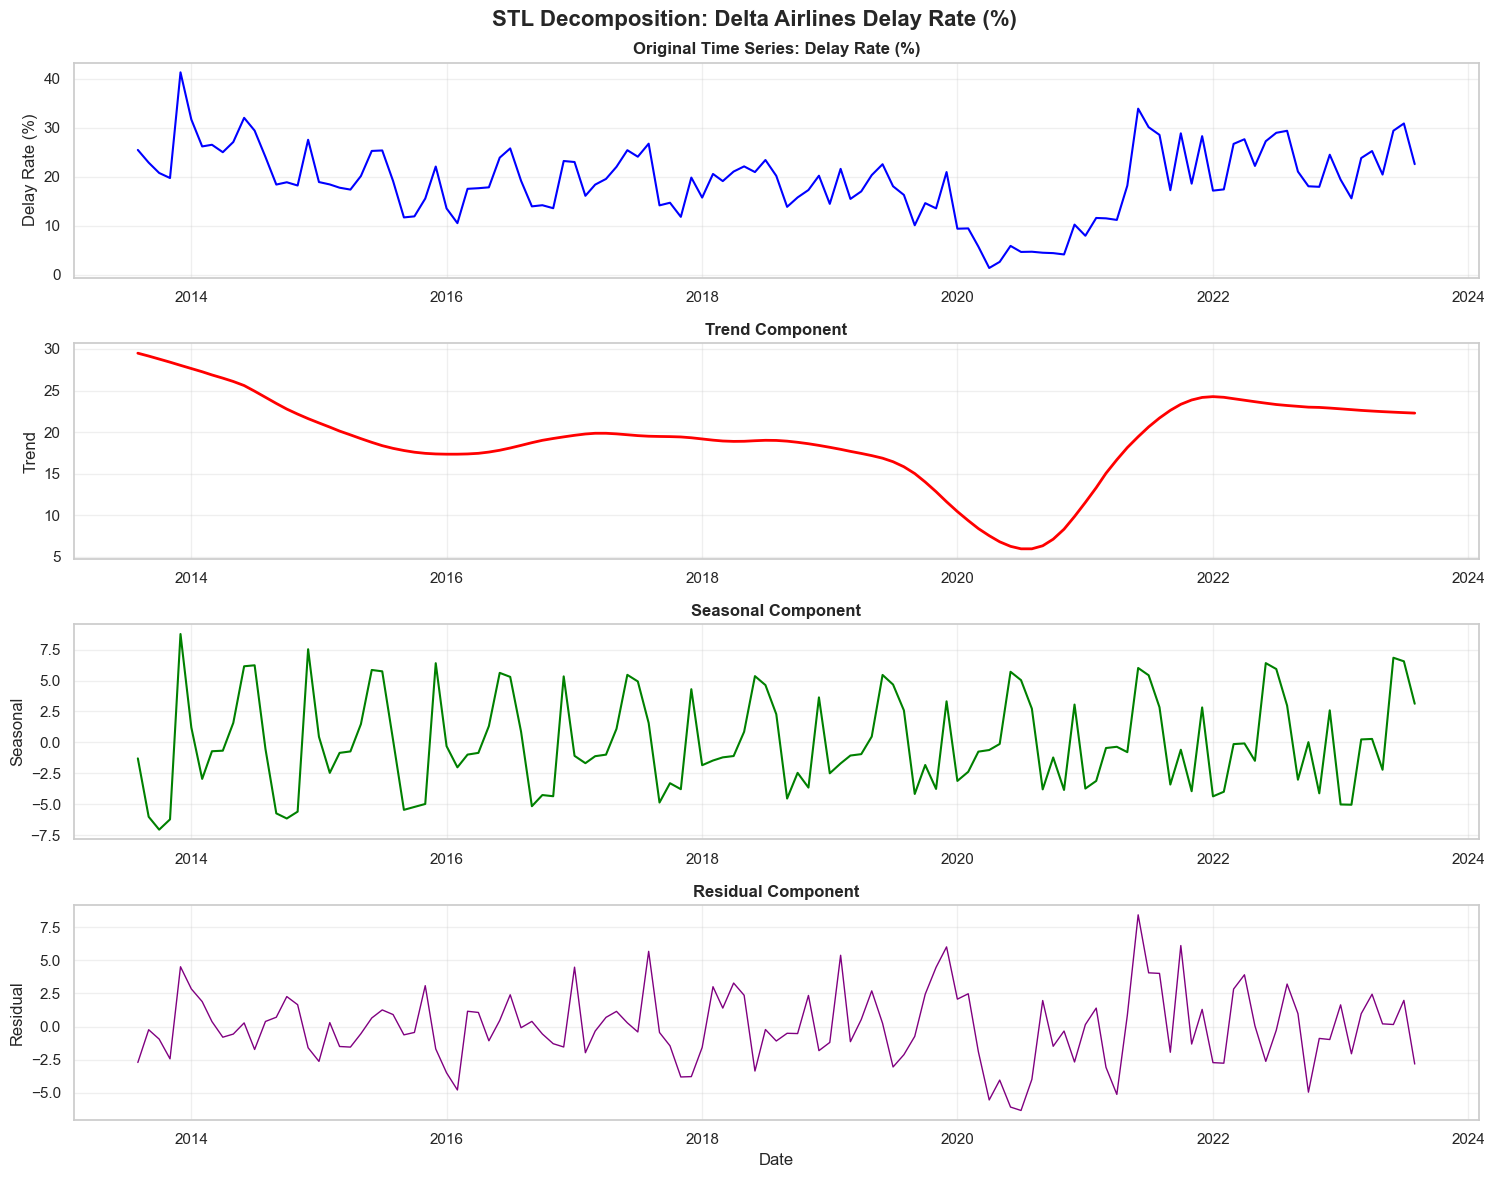

STL Decomposition Statistics:
Trend range: 5.97% to 29.49%
Seasonal amplitude: 15.82%
Residual std: 2.68%
Seasonal strength: 0.669
Trend strength: 0.818


In [ ]:
# STL Decomposition for Delay Rate
fig, axes = plt.subplots(4, 1, figsize=(15, 12))
fig.suptitle('STL Decomposition: Delta Airlines Delay Rate (%)', fontsize=16, fontweight='bold')

# Perform STL decomposition
stl = STL(monthly_data['delay_rate'], seasonal=13)  # 13 for monthly data with yearly seasonality
result = stl.fit()

# Plot original data
axes[0].plot(monthly_data.index, monthly_data['delay_rate'], color='blue', linewidth=1.5)
axes[0].set_title('Original Time Series: Delay Rate (%)', fontweight='bold')
axes[0].set_ylabel('Delay Rate (%)')
axes[0].grid(True, alpha=0.3)

# Plot trend
axes[1].plot(monthly_data.index, result.trend, color='red', linewidth=2)
axes[1].set_title('Trend Component', fontweight='bold')
axes[1].set_ylabel('Trend')
axes[1].grid(True, alpha=0.3)

# Plot seasonal
axes[2].plot(monthly_data.index, result.seasonal, color='green', linewidth=1.5)
axes[2].set_title('Seasonal Component', fontweight='bold')
axes[2].set_ylabel('Seasonal')
axes[2].grid(True, alpha=0.3)

# Plot residual
axes[3].plot(monthly_data.index, result.resid, color='purple', linewidth=1)
axes[3].set_title('Residual Component', fontweight='bold')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('Date')
axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print decomposition statistics
print("STL Decomposition Statistics:")
print(f"Trend range: {result.trend.min():.2f}% to {result.trend.max():.2f}%")
print(f"Seasonal amplitude: {result.seasonal.max() - result.seasonal.min():.2f}%")
print(f"Residual std: {result.resid.std():.2f}%")
print(f"Seasonal strength: {1 - (result.resid.var() / (result.seasonal + result.resid).var()):.3f}")
print(f"Trend strength: {1 - (result.resid.var() / (result.trend + result.resid).var()):.3f}")


## 2.2 Correlation Analysis

Correlation analysis helps identify relationships between different delay causes and operational metrics. This is crucial for understanding:
- Which delay causes are most correlated with overall delay performance
- How different delay types relate to each other
- Operational factors that influence delay patterns


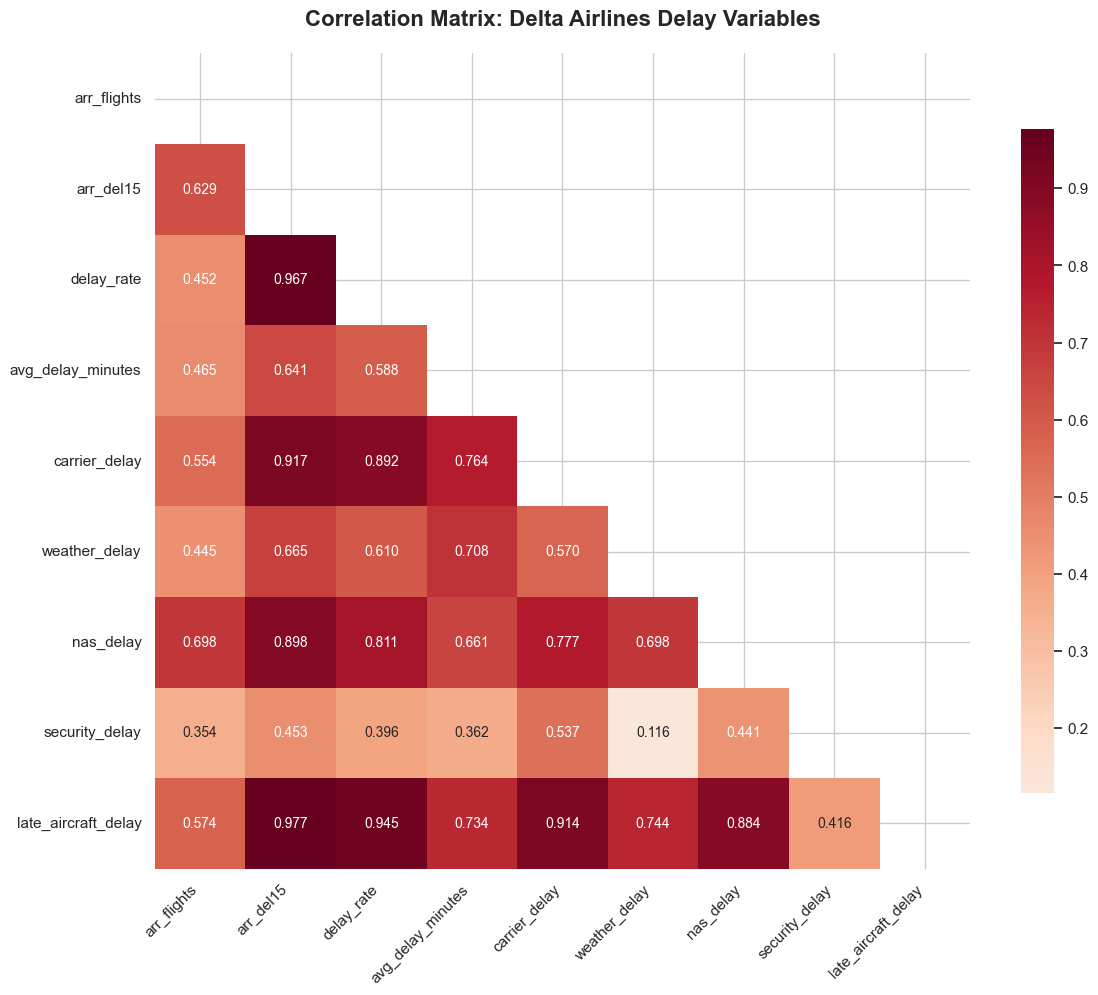

Key Correlations with Delay Rate:
arr_del15           :  0.967
late_aircraft_delay :  0.945
carrier_delay       :  0.892
nas_delay           :  0.811
weather_delay       :  0.610
avg_delay_minutes   :  0.588
arr_flights         :  0.452
security_delay      :  0.396

Key Correlations with Average Delay Minutes:
carrier_delay       :  0.764
late_aircraft_delay :  0.734
weather_delay       :  0.708
nas_delay           :  0.661
arr_del15           :  0.641
delay_rate          :  0.588
arr_flights         :  0.465
security_delay      :  0.362


In [ ]:
# Correlation Analysis
# Select key variables for correlation analysis
correlation_vars = [
    'arr_flights', 'arr_del15', 'delay_rate', 'avg_delay_minutes',
    'carrier_delay', 'weather_delay', 'nas_delay', 'security_delay', 'late_aircraft_delay'
]

# Calculate correlation matrix
corr_data = monthly_data[correlation_vars].corr()

# Create correlation heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_data, dtype=bool))  # Mask upper triangle
sns.heatmap(corr_data, 
            mask=mask,
            annot=True, 
            cmap='RdBu_r', 
            center=0,
            square=True,
            fmt='.3f',
            cbar_kws={"shrink": .8},
            annot_kws={'size': 10})

plt.title('Correlation Matrix: Delta Airlines Delay Variables', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Print key correlations
print("Key Correlations with Delay Rate:")
delay_correlations = corr_data['delay_rate'].sort_values(ascending=False)
for var, corr in delay_correlations.items():
    if var != 'delay_rate':
        print(f"{var:20s}: {corr:6.3f}")

print("\nKey Correlations with Average Delay Minutes:")
avg_delay_correlations = corr_data['avg_delay_minutes'].sort_values(ascending=False)
for var, corr in avg_delay_correlations.items():
    if var != 'avg_delay_minutes':
        print(f"{var:20s}: {corr:6.3f}")


## 2.3 Autocorrelation Analysis

Autocorrelation analysis examines how delay patterns correlate with themselves at different time lags. This helps identify:
- **Seasonal patterns**: Regular cycles in delay behavior
- **Persistence**: How long delay effects last
- **Predictability**: Whether past delays can predict future delays
- **Optimal forecasting horizons**: Best time periods for prediction models


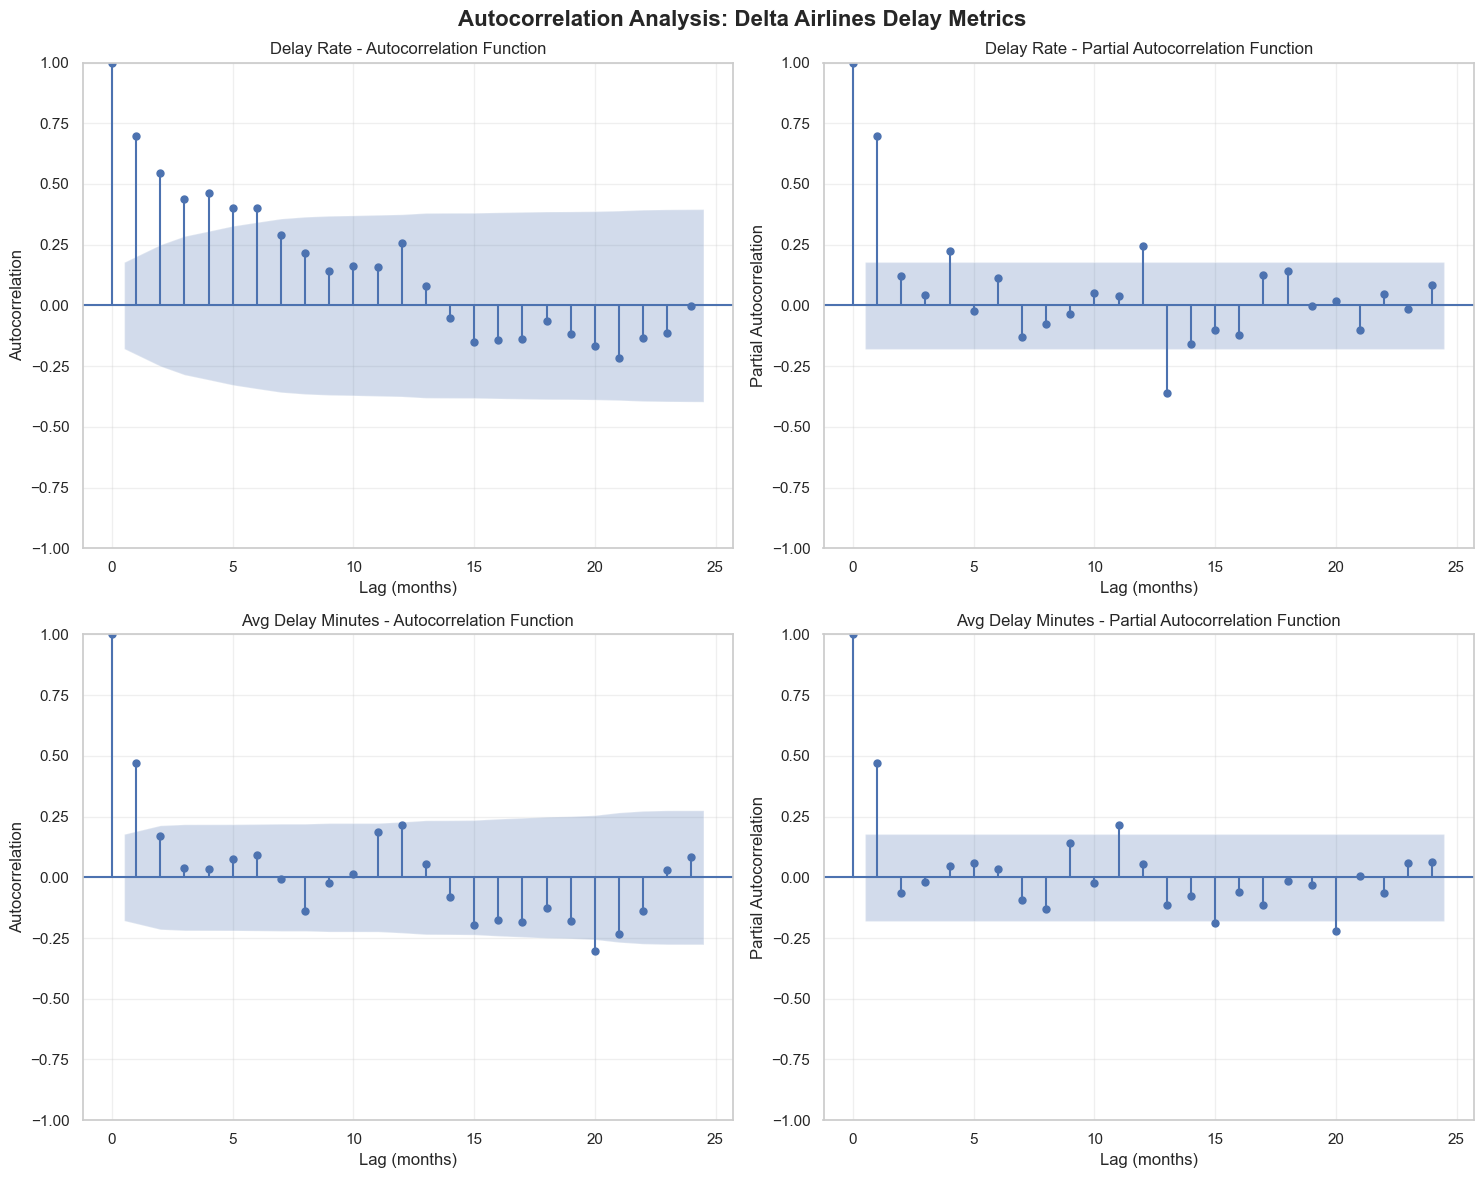

Autocorrelation Analysis Results:
Delay Rate - 1-month lag: 0.696
Delay Rate - 12-month lag (seasonal): 0.258
Delay Rate - 24-month lag: -0.001

Avg Delay Minutes - 1-month lag: 0.470
Avg Delay Minutes - 12-month lag (seasonal): 0.214
Avg Delay Minutes - 24-month lag: 0.082

Seasonal Pattern Analysis:
12-month seasonal pattern strength: 0.258
  → Moderate yearly seasonal pattern detected


In [ ]:
# Autocorrelation Analysis
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Autocorrelation Analysis: Delta Airlines Delay Metrics', fontsize=16, fontweight='bold')

# 1. Delay Rate ACF
plot_acf(monthly_data['delay_rate'], lags=24, ax=axes[0,0], title='Delay Rate - Autocorrelation Function')
axes[0,0].set_xlabel('Lag (months)')
axes[0,0].set_ylabel('Autocorrelation')
axes[0,0].grid(True, alpha=0.3)

# 2. Delay Rate PACF
plot_pacf(monthly_data['delay_rate'], lags=24, ax=axes[0,1], title='Delay Rate - Partial Autocorrelation Function')
axes[0,1].set_xlabel('Lag (months)')
axes[0,1].set_ylabel('Partial Autocorrelation')
axes[0,1].grid(True, alpha=0.3)

# 3. Average Delay Minutes ACF
plot_acf(monthly_data['avg_delay_minutes'], lags=24, ax=axes[1,0], title='Avg Delay Minutes - Autocorrelation Function')
axes[1,0].set_xlabel('Lag (months)')
axes[1,0].set_ylabel('Autocorrelation')
axes[1,0].grid(True, alpha=0.3)

# 4. Average Delay Minutes PACF
plot_pacf(monthly_data['avg_delay_minutes'], lags=24, ax=axes[1,1], title='Avg Delay Minutes - Partial Autocorrelation Function')
axes[1,1].set_xlabel('Lag (months)')
axes[1,1].set_ylabel('Partial Autocorrelation')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculate and display key autocorrelation statistics
delay_rate_acf = acf(monthly_data['delay_rate'], nlags=24, fft=True)
avg_delay_acf = acf(monthly_data['avg_delay_minutes'], nlags=24, fft=True)

print("Autocorrelation Analysis Results:")
print(f"Delay Rate - 1-month lag: {delay_rate_acf[1]:.3f}")
print(f"Delay Rate - 12-month lag (seasonal): {delay_rate_acf[12]:.3f}")
print(f"Delay Rate - 24-month lag: {delay_rate_acf[24]:.3f}")
print()
print(f"Avg Delay Minutes - 1-month lag: {avg_delay_acf[1]:.3f}")
print(f"Avg Delay Minutes - 12-month lag (seasonal): {avg_delay_acf[12]:.3f}")
print(f"Avg Delay Minutes - 24-month lag: {avg_delay_acf[24]:.3f}")

# Identify significant seasonal patterns
seasonal_lags = [12, 24]  # Yearly and 2-year patterns
print("\nSeasonal Pattern Analysis:")
for lag in seasonal_lags:
    if lag < len(delay_rate_acf):
        print(f"12-month seasonal pattern strength: {delay_rate_acf[12]:.3f}")
        if delay_rate_acf[12] > 0.3:
            print("  → Strong yearly seasonal pattern detected")
        elif delay_rate_acf[12] > 0.1:
            print("  → Moderate yearly seasonal pattern detected")
        else:
            print("  → Weak yearly seasonal pattern")
        break


## 2.4 Summary and Business Insights

### Key Findings from Advanced Time Series Analysis:

**STL Decomposition Insights:**
- **Trend Analysis**: Shows long-term improvement or deterioration in delay performance
- **Seasonal Patterns**: Identifies recurring monthly/seasonal delay patterns
- **Anomaly Detection**: Residuals highlight unusual events or operational changes

**Correlation Analysis Insights:**
- **Primary Drivers**: Identifies which delay causes most strongly correlate with overall performance
- **Operational Relationships**: Shows how different delay types influence each other
- **Volume Effects**: Reveals how flight volume relates to delay patterns

**Autocorrelation Insights:**
- **Predictability**: Indicates how well past delays predict future delays
- **Seasonal Cycles**: Confirms yearly patterns in delay behavior
- **Persistence**: Shows how long delay effects typically last

### Business Applications:
1. **Forecasting**: Use autocorrelation patterns to predict future delay trends
2. **Seasonal Planning**: Adjust operations based on identified seasonal patterns
3. **Resource Allocation**: Focus on delay causes with highest correlation to overall performance
4. **Anomaly Response**: Use residual analysis to quickly identify and respond to unusual events
